# Predikcija kategorije proizvoda na osnovu naslova

# 1. Uvod

Cilj projekta je izrada modela koji predviđa kategoriju proizvoda na osnovu njegovog naziva.

# 2. import biblioteka

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. učitavanje podataka

In [123]:
# load dataset from GitHub
url = "https://raw.githubusercontent.com/Bojan-Rajic/predikcija-kategorije-proizvoda/main/data/products.csv"

df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df.head()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


# 4. osnovni pregled podataka

In [124]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

# 5. čišćenje

In [125]:

# uklanjanje razmaka iz naziva kolona
df.columns = df.columns.str.strip()

def clean_labels(df):
    df["Category Label"] = (
        df["Category Label"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    mapping = {
        "mobile phone": "mobile phones",
        "cpu": "cpus",
        "fridge": "fridges",
    }

    df["Category Label"] = df["Category Label"].replace(mapping)

    return df

df = clean_labels(df)

# 6. distribucija kategorija

In [126]:
df["Category Label"].value_counts()

Category Label
fridge freezers     5495
mobile phones       4075
washing machines    4036
cpus                3855
fridges             3580
tvs                 3564
dishwashers         3418
digital cameras     2696
microwaves          2338
freezers            2210
nan                   44
Name: count, dtype: int64

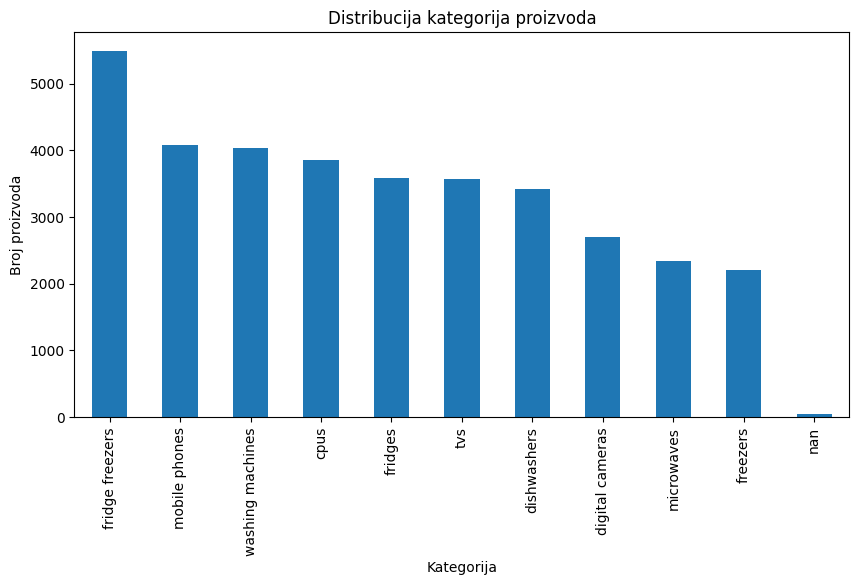

In [127]:
df["Category Label"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Distribucija kategorija proizvoda")
plt.xlabel("Kategorija")
plt.ylabel("Broj proizvoda")
plt.show()

# 7. čišćenje podataka

In [128]:
# uklanjanje nedostajućih vrednosti iz ključnih kolona
df = df.dropna(subset=["Product Title", "Category Label"])

# 8. inženjering

In [129]:
# dužina naziva proizvoda
df["title_length"] = df["Product Title"].str.len()

# 9. analiza dužine naziva

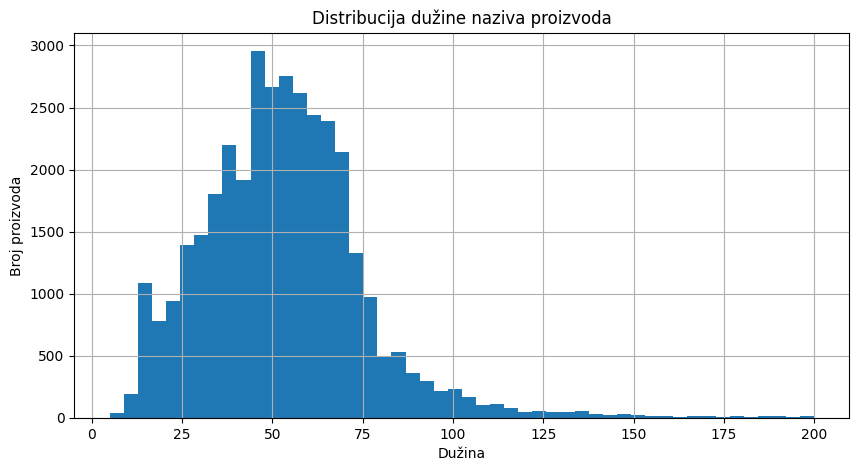

In [130]:
df["title_length"].hist(bins=50, figsize=(10,5))
plt.title("Distribucija dužine naziva proizvoda")
plt.xlabel("Dužina")
plt.ylabel("Broj proizvoda")
plt.show()

# 10. dužina po kategoriji

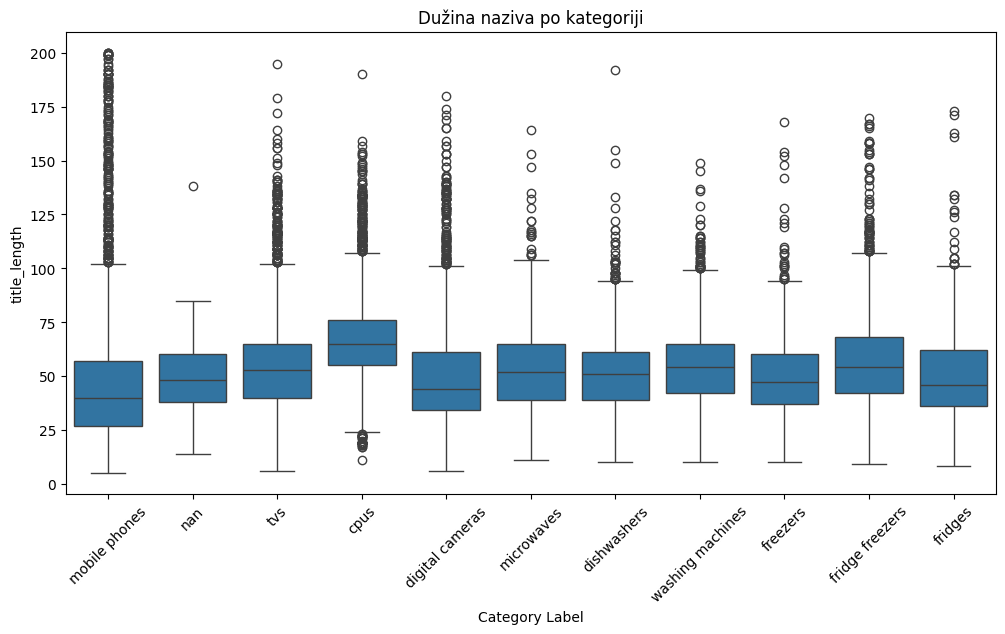

In [131]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Category Label", y="title_length", data=df)
plt.xticks(rotation=45)
plt.title("Dužina naziva po kategoriji")
plt.show()

# 11. priprema podataka

In [132]:
X = df["Product Title"]
y = df["Category Label"]

# 12. split podataka

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 13. treniranje modela

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    print("\n", name)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(classification_report(y_test, y_pred))


 Logistic Regression


c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                  precision    recall  f1-score   support

            cpus       1.00      0.99      1.00       766
 digital cameras       0.99      0.99      0.99       538
     dishwashers       0.92      0.97      0.94       681
        freezers       0.99      0.93      0.96       440
 fridge freezers       0.95      0.93      0.94      1094
         fridges       0.88      0.91      0.90       712
      microwaves       0.99      0.94      0.97       466
   mobile phones       0.96      0.99      0.97       811
             nan       0.00      0.00      0.00         9
             tvs       0.97      0.98      0.97       708
washing machines       0.94      0.94      0.94       803

        accuracy                           0.96      7028
       macro avg       0.87      0.87      0.87      7028
    weighted avg       0.96      0.96      0.96      7028


 Naive Bayes


c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                  precision    recall  f1-score   support

            cpus       1.00      1.00      1.00       766
 digital cameras       0.99      0.99      0.99       538
     dishwashers       0.98      0.96      0.97       681
        freezers       1.00      0.54      0.70       440
 fridge freezers       0.78      0.98      0.87      1094
         fridges       0.91      0.86      0.88       712
      microwaves       0.99      0.97      0.98       466
   mobile phones       0.99      0.99      0.99       811
             nan       0.00      0.00      0.00         9
             tvs       0.98      0.99      0.99       708
washing machines       0.98      0.96      0.97       803

        accuracy                           0.94      7028
       macro avg       0.87      0.84      0.85      7028
    weighted avg       0.95      0.94      0.94      7028


 Decision Tree
                  precision    recall  f1-score   support

            cpus       1.00      0.99      1.00     

c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bojan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                  precision    recall  f1-score   support

            cpus       1.00      1.00      1.00       766
 digital cameras       0.99      0.99      0.99       538
     dishwashers       0.95      0.92      0.93       681
        freezers       0.92      0.94      0.93       440
 fridge freezers       0.91      0.94      0.93      1094
         fridges       0.91      0.88      0.90       712
      microwaves       0.94      0.97      0.95       466
   mobile phones       0.98      0.98      0.98       811
             nan       0.00      0.00      0.00         9
             tvs       0.99      0.99      0.99       708
washing machines       0.95      0.94      0.94       803

        accuracy                           0.95      7028
       macro avg       0.87      0.87      0.87      7028
    weighted avg       0.95      0.95      0.95      7028


 SVM
                  precision    recall  f1-score   support

            cpus       1.00      1.00      1.00       766
 dig

In [135]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = (y_pred == y_test).mean()

    results.append((name, acc))

results = sorted(results, key=lambda x: x[1], reverse=True)

print("\nModel ranking:")
for r in results:
    print(r)


Model ranking:
('SVM', np.float64(0.9704040978941377))
('Logistic Regression', np.float64(0.9567444507683551))
('Random Forest', np.float64(0.954183266932271))
('Naive Bayes', np.float64(0.938958451906659))
('Decision Tree', np.float64(0.9368241320432555))


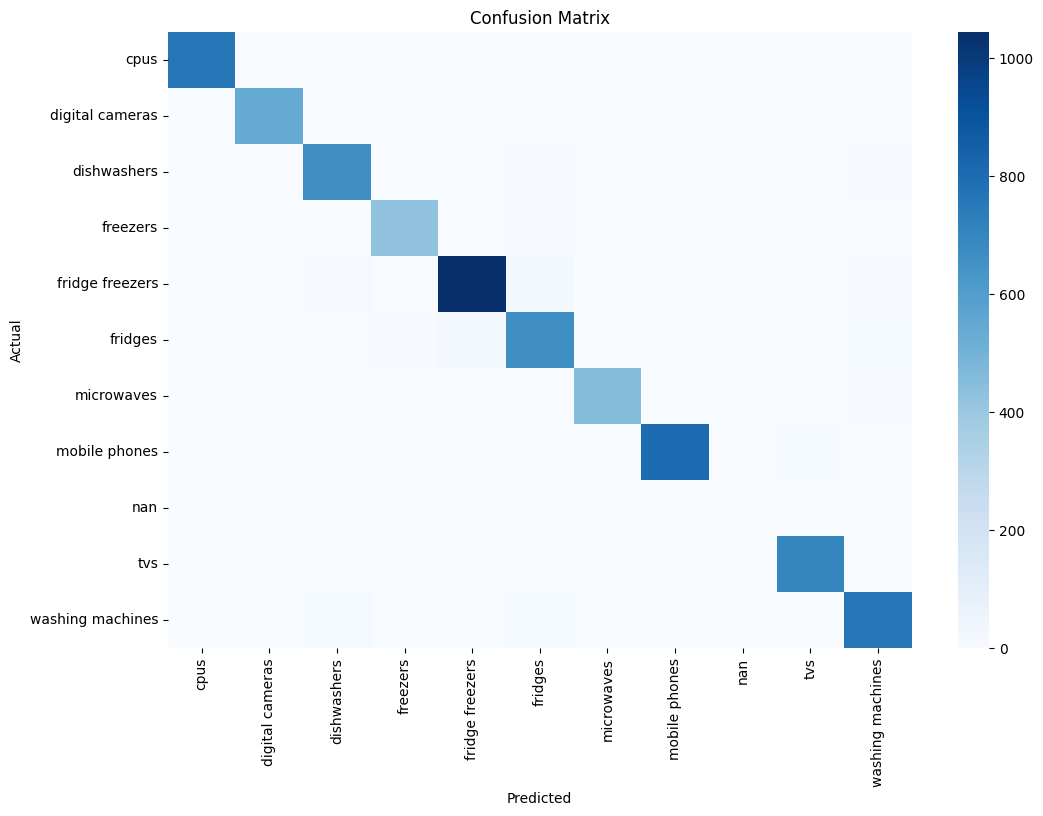

In [136]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Zaključak

Najbolji model za ovaj problem je LinearSVC (SVM), koji postiže najvišu tačnost u poređenju sa ostalim modelima.

Model uspešno klasifikuje nazive proizvoda u odgovarajuće kategorije koristeći TF-IDF reprezentaciju teksta.